# THEGCN — Threshold Tuning & Evaluation

Looks up the best run from MLflow experiment `thegcn-test` by `val_auc`, loads the saved `.pth` from `saved_models/`, tunes the decision threshold on the **val set** by maximising MCC, then reports all metrics on the **test set**.

## Imports & setup

In [1]:
import os
import sys
import warnings
import logging

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    matthews_corrcoef,
    recall_score,
    precision_score,
    roc_curve,
    precision_recall_curve,
)
from utils import recall_at_top_n_percent
from torch_geometric.loader import NeighborLoader
from models import THEGCNModel

import mlflow
import matplotlib.pyplot as plt

from namespaces import DA
from dgraphfin import DGraphFin, load_dgraphfin_temporal  # reuse existing dataset class
# from sampler import TemporalSampler, load_sampler_data

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARN)

DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)


/home/mai/notebooks/final_thesis/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.chdir('/home/mai/notebooks/final_thesis/')
sys.path.insert(0, './src')
# os.makedirs('./eval_plots', exist_ok=True)

In [3]:
from models import THEGCNModel

## Find best run in MLflow

In [4]:
# Search MLflow for the best TGAT run by val_auc
experiment_name = 'thegcn-test-tanh'
metric_name     = 'val_auc'

exp  = mlflow.get_experiment_by_name(experiment_name)
runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    order_by=[f"metrics.{metric_name} DESC"],
    max_results=1,
)

best_run    = runs.iloc[0]
best_run_id = best_run["run_id"]

prefix = best_run["params.prefix"]
data   = best_run["params.data"]

print("Best run ID  :", best_run_id)
print(f"Best {metric_name} :", best_run[f"metrics.{metric_name}"])

MlflowException: Detected out-of-date database schema (found version 1b5f0d9ad7c1, but expected c3d6457b6d8a). Take a backup of your database, then run 'mlflow db upgrade <database_uri>' to migrate your database to the latest schema. NOTE: schema migration may result in database downtime - please consult your database's documentation for more detail.

## Recover model path from logged params

In [ ]:
model_path  = f'./saved_models/thegcn-{prefix}-node-{data}.pth'
# PLOT_PREFIX = f'./eval_plots/{prefix}-tgat-{data}'
print("Model path  :", model_path)

Model path  : ./saved_models/thegcn-run1-node-DGraphFin.pth


In [5]:
# ── Architecture config — must match the values used during training ──────────
NODE_DIM        = int(best_run['params.node_dim'])
TIME_DIM        = int(best_run['params.time_dim'])
N_LAYER         = int(best_run['params.n_layer'])
# N_HEAD          = int(best_run['params.n_head'])
N_NEIGHBOR      = int(best_run['params.n_neighbor'])
BATCH_SIZE      = int(best_run['params.bs']) * 2
NUM_WORKERS     = int(best_run['params.num_workers'])
N_THRESHOLD     = 500
DROP_OUT        = float(best_run['params.drop_out'])
GPU             = int(best_run['params.gpu'])
FOLD            = 0
DATA_DIR        = './datasets'

NameError: name 'best_run' is not defined

## Load data

In [7]:
(graph, train_idx, val_idx, test_idx,
 train_labels_np, node_feat_dim) = load_dgraphfin_temporal(
    data_dir=DATA_DIR, fold=FOLD, to_undirected=False,
)
print(f'Graph : {graph.num_nodes:,} nodes | {graph.num_edges:,} edges')
print(f'Val   : {len(val_idx):,} nodes')
print(f'Test  : {len(test_idx):,} nodes')

Graph : 3,700,550 nodes | 4,300,999 edges
Val   : 183,862 nodes
Test  : 183,840 nodes


In [8]:
device = torch.device(f'cuda:{GPU}' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda:0


## NeighborLoaders

In [11]:
if N_LAYER == 1:
    num_neighbors = [N_NEIGHBOR]
elif N_LAYER == 2:
    num_neighbors = [N_NEIGHBOR, 5]
else:
    step = max(1, (N_NEIGHBOR - 5) // (N_LAYER - 1))
    num_neighbors = [max(5, N_NEIGHBOR - i * step) for i in range(N_LAYER)]
    # num_neighbors = [N_NEIGHBOR] * N_LAYER

print('NeighborLoader fanouts:', num_neighbors)

val_loader = NeighborLoader(
    graph,
    num_neighbors = num_neighbors,
    batch_size    = BATCH_SIZE * 2,
    input_nodes   = val_idx,
    input_time    = graph.node_time[val_idx],
    time_attr     = 'edge_time',
    shuffle       = False,
    num_workers   = NUM_WORKERS,
)

test_loader = NeighborLoader(
    graph,
    num_neighbors = num_neighbors,
    batch_size    = BATCH_SIZE * 2,
    input_nodes   = test_idx,
    input_time    = graph.node_time[test_idx],
    time_attr     = 'edge_time',
    shuffle       = False,
    num_workers   = NUM_WORKERS,
)

NeighborLoader fanouts: [10, 5]


## Load saved weights

In [12]:
gnn = THEGCNModel(
    in_channels     = node_feat_dim,
    hidden_channels = NODE_DIM,
    n_smp_layers    = N_LAYER,
    time_dim        = TIME_DIM,
    dropout         = DROP_OUT,
).to(device)

gnn.load_state_dict(torch.load(model_path, map_location=device))
gnn.eval()
print(f'Loaded  : {model_path}')
print(f'Params  : {sum(p.numel() for p in gnn.parameters()):,}')

Loaded  : ./saved_models/thegcn-run1-node-DGraphFin.pth
Params  : 137,250


## Inference helper

In [13]:
@torch.no_grad()
def get_scores(loader, desc='Inference'):
    all_scores, all_labels = [], []
    for batch in tqdm(loader, desc=desc):
        batch      = batch.to(device, non_blocking=True)
        batch_size = batch.batch_size
        logits = gnn(
            x          = batch.x,
            edge_index = batch.edge_index,
            time       = batch.edge_time,
            node_time  = batch.node_time,
            batch_size = batch_size,
        )
        all_scores.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(batch.y[:batch_size].cpu().numpy())
    return np.concatenate(all_scores), np.concatenate(all_labels)

## Cutoff selection — maximise MCC on val set

Val inference: 100%|██████████| 45/45 [00:00<00:00, 51.95it/s]


Best cutoff : 0.9439
Val MCC     : 0.4405


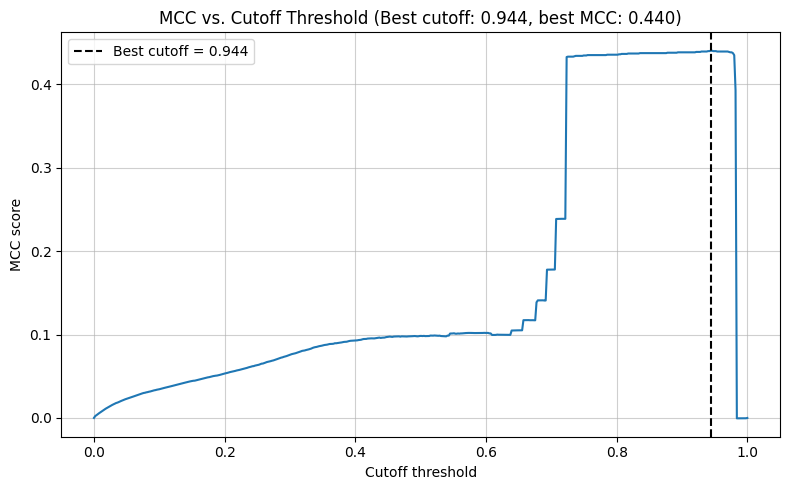

In [14]:
# ── Cutoff selection to maximise MCC (val set) ───────────────────────────────
y_prob_val, y_true_val = get_scores(val_loader, desc='Val inference')

thresholds = np.linspace(0, 1, N_THRESHOLD)
mcc_scores = []
for t in thresholds:
    y_pred = (y_prob_val >= t).astype(int)
    mcc_scores.append(matthews_corrcoef(y_true_val, y_pred))

best_idx       = np.argmax(mcc_scores)
best_threshold = thresholds[best_idx]
best_mcc       = mcc_scores[best_idx]

print(f'Best cutoff : {best_threshold:.4f}')
print(f'Val MCC     : {best_mcc:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(thresholds, mcc_scores)
plt.axvline(best_threshold, ls='--', color='k',
            label=f'Best cutoff = {best_threshold:.3f}')
plt.title(f'MCC vs. Cutoff Threshold (Best cutoff: {best_threshold:.3f}, best MCC: {best_mcc:.3f})')
plt.xlabel('Cutoff threshold')
plt.ylabel('MCC score')
plt.legend()
plt.grid(True, axis='both', alpha=0.6)
plt.tight_layout()
# plt.savefig(f'{PLOT_PREFIX}-mcc-threshold.png', dpi=150)
plt.show()

## Test-set evaluation

In [15]:
# ── Apply best threshold to test set ─────────────────────────────────────────
y_prob, y_true = get_scores(test_loader, desc='Test inference')
y_pred = (y_prob >= best_threshold).astype(int)

auc = roc_auc_score(y_true, y_prob)
ap  = average_precision_score(y_true, y_prob)
f1  = f1_score(y_true, y_pred,  zero_division=0)
mcc = matthews_corrcoef(y_true, y_pred)
rc  = recall_score(y_true, y_pred, zero_division=0)
pr  = precision_score(y_true, y_pred, zero_division=0)
rc_at_1 = recall_at_top_n_percent(y_true, y_prob, n_percent=1)
rc_at_10 = recall_at_top_n_percent(y_true, y_prob, n_percent=10)

print(f'AUC       : {auc:.4f}')
print(f'AP        : {ap:.4f}')
print(f'F1        : {f1:.4f}')
print(f'MCC       : {mcc:.4f}')
print(f'Recall    : {rc:.4f}')
print(f'Precision : {pr:.4f}')
print(f'Recall at 1% : {rc_at_1:.4f}')
print(f'Recall at 10% : {rc_at_10:.4f}')

Test inference: 100%|██████████| 45/45 [00:00<00:00, 76.79it/s]


AUC       : 0.7878
AP        : 0.1966
F1        : 0.2833
MCC       : 0.4010
Recall    : 0.1655
Precision : 0.9821
Recall at 1% : 0.1922
Recall at 10% : 0.3633


## ROC Curve

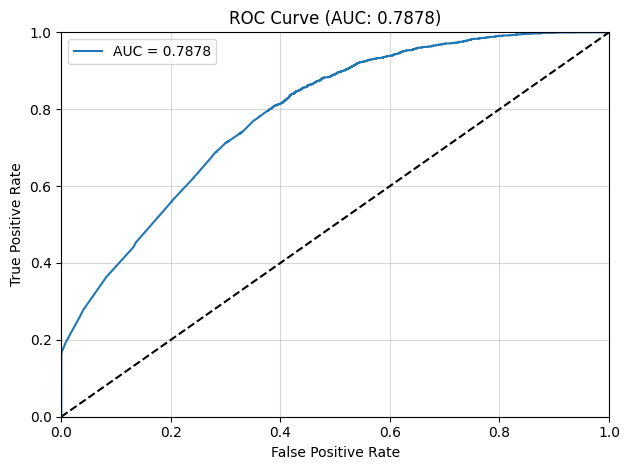

In [16]:
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], ls='--', color='k')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC: {auc:.4f})')
plt.xlim(0, 1); plt.ylim(0, 1)
plt.legend()
plt.grid(True, axis='both', alpha=0.5)
plt.tight_layout()
# plt.savefig(f'{PLOT_PREFIX}-roc.png', dpi=150)
plt.show()

## Precision-Recall Curve

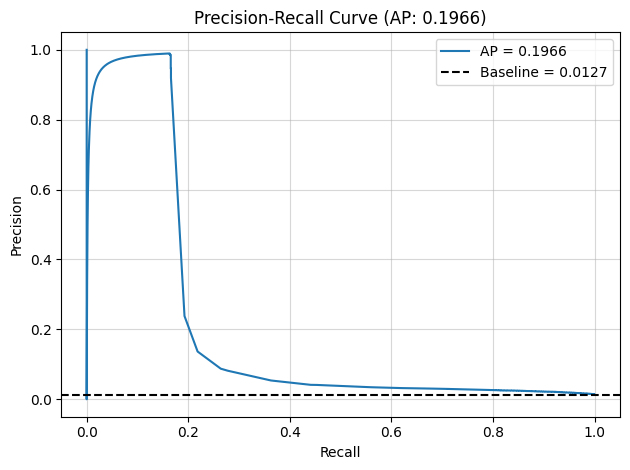

In [17]:
prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
baseline = np.mean(y_true)

plt.figure()
plt.plot(rec_curve, prec_curve, label=f'AP = {ap:.4f}')
plt.axhline(baseline, linestyle='--', color='k', label=f'Baseline = {baseline:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (AP: {ap:.4f})')
plt.legend()
plt.grid(True, axis='both', alpha=0.5)
plt.tight_layout()
# plt.savefig(f'{PLOT_PREFIX}-pr.png', dpi=150)
plt.show()

## Gain & Lift Charts

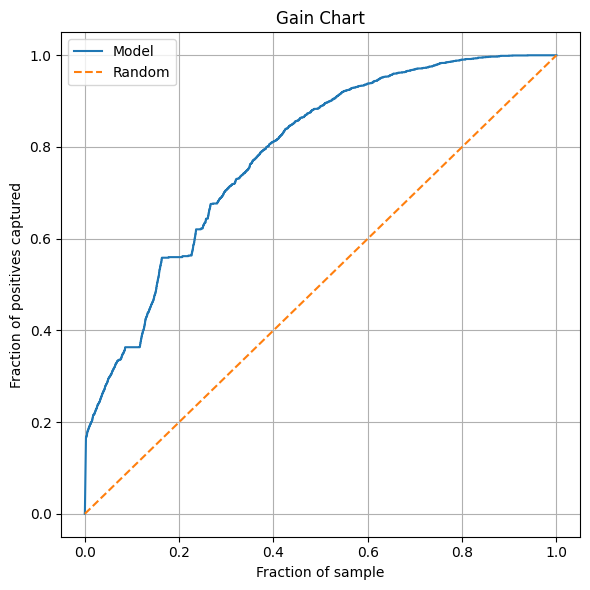

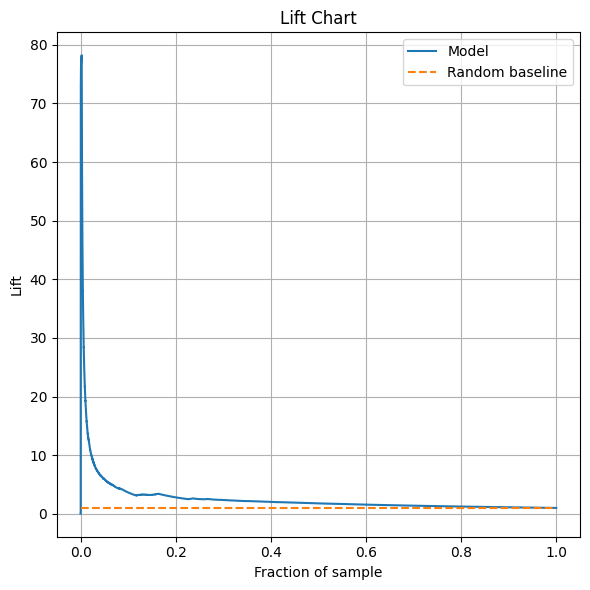

In [18]:
gl = pd.DataFrame({'y_test': y_true, 'y_prob': y_prob})
gl = gl.sort_values('y_prob', ascending=False).reset_index(drop=True)
gl['cum_positives'] = gl['y_test'].cumsum()
gl['gain']          = gl['cum_positives'] / gl['y_test'].sum()
gl['samples_frac']  = np.arange(1, len(gl) + 1) / len(gl)

plt.figure(figsize=(6, 6))
plt.plot(gl['samples_frac'], gl['gain'], label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
plt.xlabel('Fraction of sample')
plt.ylabel('Fraction of positives captured')
plt.title('Gain Chart')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(f'{PLOT_PREFIX}-gain.png', dpi=150)
plt.show()

gl['lift'] = gl['gain'] / gl['samples_frac']

plt.figure(figsize=(6, 6))
plt.plot(gl['samples_frac'], gl['lift'], label='Model')
plt.plot([0, 1], [1, 1], linestyle='--', label='Random baseline')
plt.xlabel('Fraction of sample')
plt.ylabel('Lift')
plt.title('Lift Chart')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(f'{PLOT_PREFIX}-lift.png', dpi=150)
plt.show()

## KS Plot

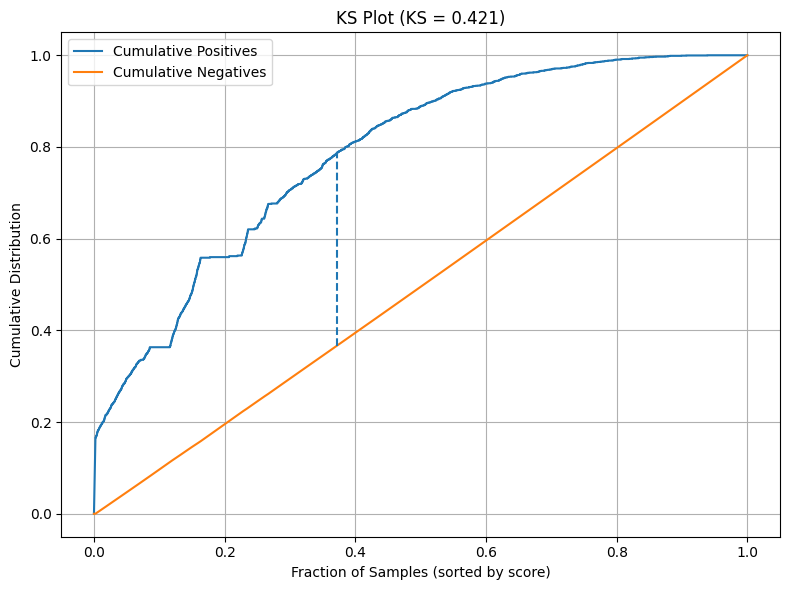

KS statistic : 0.4214
Plots saved  : ./eval_plots/


In [19]:
gl['neg']           = 1 - gl['y_test']
gl['cum_negatives'] = gl['neg'].cumsum()
gl['cum_pos_rate']  = gl['cum_positives'] / gl['cum_positives'].iloc[-1]
gl['cum_neg_rate']  = gl['cum_negatives'] / gl['cum_negatives'].iloc[-1]
gl['ks']            = gl['cum_pos_rate'] - gl['cum_neg_rate']

ks_value = gl['ks'].abs().max()
ks_idx   = gl['ks'].abs().idxmax()

plt.figure(figsize=(8, 6))
plt.plot(gl['samples_frac'], gl['cum_pos_rate'], label='Cumulative Positives')
plt.plot(gl['samples_frac'], gl['cum_neg_rate'], label='Cumulative Negatives')
plt.vlines(gl.loc[ks_idx, 'samples_frac'],
           gl.loc[ks_idx, 'cum_neg_rate'],
           gl.loc[ks_idx, 'cum_pos_rate'],
           linestyles='dashed')
plt.title(f'KS Plot (KS = {ks_value:.3f})')
plt.xlabel('Fraction of Samples (sorted by score)')
plt.ylabel('Cumulative Distribution')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(f'{PLOT_PREFIX}-ks.png', dpi=150)
plt.show()

print(f'KS statistic : {ks_value:.4f}')
print(f'Plots saved  : ./eval_plots/')